# From Red Flags to Detection Rules
## An LLM-driven Pipeline for Real-Time GOOSE Intrusion Detection and Prevention

> **Autores:** Lucas A. Martins¹*, Camilla B. Quincozes², Silvio E. Quincozes¹², Marcelo Luizelle², Giovanni Siervo  
> ¹ Universidade Federal de Uberlândia (UFU) – Uberlândia, Brasil  
> ² Universidade Federal do Pampa (UNIPAMPA) – Alegrete, Brasil  
> `{lucas.martins, sequincozes}@ufu.br`

---

### Resumo

Sistemas de Detecção de Intrusão (IDS) baseados em especificação são amplamente utilizados em subestações IEC 61850, mas dependem de regras criadas manualmente por especialistas. Este notebook apresenta um **pipeline orientado por LLM** que automatiza a geração de regras de detecção para detecção e prevenção de intrusões GOOSE em tempo real.

A abordagem utiliza amostras de comunicação rotuladas para identificar *red flags*, que são transformadas em regras de detecção de intrusão executáveis. A prova de conceito usa o **dataset ERENO** e demonstra que as regras geradas detectam comportamentos anômalos com baixo overhead operacional.

## Índice

1. [Introdução](#1-introdução)
2. [IDS Baseado em Especificação para GOOSE](#2-ids-baseado-em-especificação-para-goose)
3. [Arquitetura Proposta](#3-arquitetura-proposta)
4. [Instalação e Configuração do Ambiente](#4-instalação-e-configuração-do-ambiente)
5. [Ingestão de Dados (ERENO)](#5-ingestão-de-dados-ereno)
6. [Extração de Red Flags e Criação de Regras](#6-extração-de-red-flags-e-criação-de-regras)
   - 6.1 [Extração de Red Flags](#61-extração-de-red-flags)
   - 6.2 [Geração de Regras de Detecção](#62-geração-de-regras-de-detecção)
7. [Execução das Regras (rules.py) e registro de resultados](#7-execução-das-regras-rulespy-e-registro-de-resultados)
8. [Geração de Matriz](#8-geração-de-matriz)
   - 8.1 [Pipeline simplificado de avaliação de regras (linear)](#81-pipeline-simplificado-de-avaliação-de-regras-linear)
   - 8.2 [Pipeline completo de avaliação de regras (estruturado)](#82-pipeline-completo-de-avaliação-de-regras-estruturado)
   - 8.3 [Geração de Matriz Visual](#83-geração-de-matriz-visual)
9. [Considerações Finais](#9-considerações-finais)
10. [Referências](#10-referências)

---
## 1. Introdução

Subestações digitais baseadas no padrão **IEC–61850** enfrentam desafios crescentes de cibersegurança, incluindo ataques de:

- **Denial-of-Service (DoS)**
- **Injeção de mensagens (Message Injection)**
- **Mascaramento (Masquerade attacks)**

IDS baseados em especificação são atraentes nesse contexto por seu **baixo overhead computacional** e **interpretabilidade**. No entanto, dependem de regras escritas manualmente por especialistas — processo custoso, difícil de escalar e pouco adaptável.

**Motivação principal:** Automatizar a geração dessas regras usando LLMs a partir de amostras rotuladas do dataset ERENO–IEC–61850.

---
## 2. IDS Baseado em Especificação para GOOSE

O protocolo **GOOSE (Generic Object Oriented Substation Event)**, definido pelo padrão IEC–61850-8-1, suporta operações de proteção e controle em tempo crítico via modelo publisher/subscriber sobre Ethernet.

### Campos relevantes de um frame GOOSE

| Categoria | Campos |
|-----------|--------|
| Estruturais | `dst_mac`, `TPID`, `ethType`, `gooseAppid`, `timeAllowedToLive` |
| Consistência | `gocbRef`, `datSet`, `goID`, `t`, `stNum`, `sqNum` |
| Dinâmica | frequência de mensagens, bytes/s, pacotes/s |

> ⚠️ O GOOSE não foi projetado com mecanismos nativos de segurança robustos, tornando-o vulnerável a ataques de injeção, replay e negação de serviço.

---
## 3. Arquitetura Proposta

O pipeline é composto por **quatro estágios principais**:

```
┌─────────────────┐    ┌──────────────────┐    ┌───────────────────┐    ┌──────────────────┐
│  Dataset GOOSE  │───▶│ Red Flag Extract.│───▶│  Rule Generation  │───▶│ Switch Simulation│
│  Rotulado       │    │ (LLM-based)      │    │  (Python rules)   │    │  (Real-time)     │
│  (ERENO)        │    │                  │    │                   │    │                  │
└─────────────────┘    └──────────────────┘    └───────────────────┘    └──────────────────┘
```

| Estágio | Responsabilidade |
|---------|------------------|
| **1. Source Ingestion** | Carrega dataset, organiza features, prepara prompts estruturados |
| **2. Red Flag Extraction** | LLM identifica padrões suspeitos e inconsistências comportamentais |
| **3. Rule Generation** | Traduz red flags em regras Python executáveis |
| **4. Simulated Deployment** | Executa regras sobre tráfego GOOSE em tempo real simulado |

---
## 4. Instalação e Configuração do Ambiente

In [1]:
# Instalação das dependências (recomenda-se ambiente virtual)
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd

from groq import Groq
from dotenv import load_dotenv

load_dotenv()  # carrega variáveis do .env na sessão

api_key = os.getenv("GROQ_API_KEY")

if not api_key:
    raise RuntimeError("Defina GROQ_API_KEY no arquivo .env.")

groq_client = Groq(api_key=api_key)
engine_model = "groq/compound" #llama-3.1-8b-instant"


def get_groq_client():
    return groq_client

---
## 5. Ingestão de Dados (ERENO)

O dataset **ERENO–IEC–61850** fornece amostras rotuladas de tráfego GOOSE em condições normais e sob ataque.

Cada amostra contém features de três tipos:
- **Protocol-level:** campos do protocolo GOOSE
- **Temporal:** diferenças de timestamp entre mensagens
- **Derived:** métricas calculadas como `stDiff`, `sqDiff`, `timestampDiff`

In [3]:
from pathlib import Path

DATASET_PATH = Path("small_dataset/train.csv")

print("Dataset em:", DATASET_PATH.resolve())

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset não encontrado em {DATASET_PATH.resolve()}")

df = pd.read_csv(DATASET_PATH)

print(f"Dataset carregado: {len(df)} amostras, {df.shape[1]} features\n")

# 1) Garante que TODAS as colunas importantes + 'class' sejam consideradas
IMPORTANT_COLUMNS = [
    "SqNum",
    "StNum",
    "cbStatus",
    # "ethType",
    # "gooseAppid",
    # "gooseLen",
    # "TPID",
    # "gocbRef",
    # "datSet",
    "goID",
    # "test",
    # "confRev",
    # "numDatSetEntries",
    # "APDUSize",
    "stDiff",
    "sqDiff",
    "gooseLengthDiff",
    "cbStatusDiff",
    "apduSizeDiff",
    "frameLengthDiff",
    "timestampDiff",
    "tDiff",
    "timeFromLastChange",
    "delay",
    "class" ## A classe é importante para o modelo aprender a distinguir ataques de tráfego normal, então deve ser mantida.
]

# 2) Garante que só usa colunas que existem de fato no df
available_cols = [c for c in IMPORTANT_COLUMNS if c in df.columns]
missing_cols = [c for c in IMPORTANT_COLUMNS if c not in df.columns]

print("Colunas usadas no prompt:")
for c in available_cols:
    print(" -", c)

if missing_cols:
    print("\n[Aviso] Colunas não encontradas no dataset e ignoradas:")
    for c in missing_cols:
        print(" -", c)

# 3) Cria df_reduced COM APENAS essas colunas (todo o resto é removido)
df_reduced = df[available_cols].copy()
print(f"\nDataset reduzido: {len(df_reduced)} amostras, {df_reduced.shape[1]} features\n")

# 4) Confirmar que só sobraram colunas importantes + class:
print("Colunas finais em df_reduced:")
for col in df_reduced.columns:
    print(" -", col)

print("Primeiras linhas:")
display(df_reduced.head())


Dataset em: /home/lucas/Documentos/Mestrado/CTA/SBRC_2026/small_dataset/train.csv
Dataset carregado: 207 amostras, 52 features

Colunas usadas no prompt:
 - SqNum
 - StNum
 - cbStatus
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - timestampDiff
 - tDiff
 - timeFromLastChange
 - delay
 - class

Dataset reduzido: 207 amostras, 15 features

Colunas finais em df_reduced:
 - SqNum
 - StNum
 - cbStatus
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - timestampDiff
 - tDiff
 - timeFromLastChange
 - delay
 - class
Primeiras linhas:


,SqNum,StNum,cbStatus,goID,stDiff,sqDiff,gooseLengthDiff,cbStatusDiff,apduSizeDiff,frameLengthDiff,timestampDiff,tDiff,timeFromLastChange,delay,class
0,1.0,122.0,1.0,IntLockA,-5850.0,-80.0,0.0,1.0,0.0,0.0,0.116166,-805.919857,707.598591,0.000180,poisoned_high_rate
1,2.0,287.0,0.0,IntLockA,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.004000,0.000203,grayhole
2,16.0,275.0,0.0,IntLockA,0.0,0.0,0.0,0.0,0.0,0.0,0.003353,0.000000,1318.944666,0.000195,inverse_replay
3,3.0,40.0,1.0,IntLockA,0.0,1.0,0.0,0.0,0.0,0.0,0.004000,0.000000,0.008000,0.000028,masquerade_fake_fault
4,1.0,9773.0,1.0,IntLockA,1.0,0.0,0.0,0.0,0.0,0.0,6.438091,0.000000,58564.134007,0.000684,poisoned_high_rate


---
## 6. Extração de Red Flags e Criação de Regras

In [4]:
# import time
# import json
# from pathlib import Path

# import pandas as pd
# from groq import RateLimitError


# # 1. Selecionar amostras normais e por classe
# def sample_normal_and_attacks(
#     df: pd.DataFrame,
#     n_normal: int = 20,
#     n_per_attack: int = 10,
# ) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
#     """
#     Separa um pequeno conjunto de referência normal e amostras por classe de ataque.
#     Assume que df['class'] == 'normal' para tráfego legítimo e outros valores são ataques.
#     """
#     df_normal = df[df["class"] == "normal"].sample(
#         n=min(n_normal, (df["class"] == "normal").sum()),
#         random_state=42,
#     )

#     attack_classes = sorted(c for c in df["class"].unique() if c != "normal")
#     attack_samples: dict[str, pd.DataFrame] = {}

#     for cls in attack_classes:
#         df_cls = df[df["class"] == cls]
#         attack_samples[cls] = df_cls.sample(
#             n=min(n_per_attack, len(df_cls)),
#             random_state=42,
#         )

#     return df_normal, attack_samples


# # 2. Prompt base com “referência normal”
# def make_normal_reference_block(df_normal: pd.DataFrame) -> str:
#     header = (
#         "Você é um especialista em segurança de subestações IEC 61850.\n"
#         "Abaixo estão amostras de tráfego GOOSE normal; use-as como referência\n"
#         "de comportamento legítimo. A coluna 'class' sempre é 'normal'.\n\n"
#         "=== AMOSTRAS NORMAIS (REFERÊNCIA) ===\n"
#     )
#     return header + df_normal.to_string(index=False)


# # 3. Prompt por classe de ataque para gerar regras incrementais
# def make_attack_prompt_for_rules(
#     df_normal_ref: pd.DataFrame,
#     df_attack: pd.DataFrame,
#     attack_class: str,
# ) -> str:
#     """
#     Cria um prompt compacto para uma classe de ataque específica,
#     reutilizando a mesma referência de tráfego normal.
#     """
#     normal_block = make_normal_reference_block(df_normal_ref)

#     attack_block = (
#         f"\n\n=== AMOSTRAS DE ATAQUE: {attack_class} ===\n"
#         + df_attack.to_string(index=False)
#     )

#     instructions = f"""
#         Você é um modelo especializado em detecção de intrusões em tráfego IEC 61850-GOOSE.

#         Tarefa:
#         A partir da diferença entre amostras NORMAIS (referência) e amostras de ataque da classe '{attack_class}', gere FUNÇÕES DE REGRAS DE DETECÇÃO em Python para identificar pacotes suspeitos dessa classe.

#         Regras de saída:

#         Retorne APENAS código Python válido, sem explicações, comentários extras ou markdown.

#         Crie de 3 a 5 funções com a forma:

#         def rule_{attack_class}_<nome_curto>(packet: dict) -> bool:
#         \"\"\"Retorna True se o pacote for suspeito desse ataque.\"\"\"
#         # lógica usando apenas campos presentes em packet
#         ...

#         Use nomes_curto descritivos em snake_case (ex.: jumps_stnum_time_diff, sqnum_reset_pattern).

#         Restrições:

#         NÃO use a coluna/atributo \"class\" em hipótese alguma (assuma que packet não tem essa chave).

#         Use apenas campos que existem no dataset, como por exemplo: 'StNum', 'SqNum', 'timestampDiff', 'cbStatus', 'ethSrc', 'ethDst', 'appID', flags e contadores.

#         Cada regra deve combinar DOIS OU MAIS campos (evite depender de um campo único).

#         NÃO use igualdade exata para valores específicos de timestamp, StNum ou SqNum (evite “== 42” ou “== 0.1234”).

#         PREFIRA condições relativas e comportamentais, por exemplo:

#         Comparações de maior/menor (timestampDiff muito maior ou muito menor que o normal).

#         Diferenças entre contadores ou campos derivados (ex.: timestampDiff, stNumDiff, sqNumDiff).

#         Padrões de origem/destino (ethSrc/ethDst) combinados com mudanças em StNum/SqNum.

#         Foque em captar o comportamento típico da classe '{attack_class}' em contraste com o tráfego normal (replay, jumps anômalos, resets inesperados, frequência anômala, etc.).

#         Estilo do código:

#         Use apenas operações básicas de Python (comparações, AND/OR/NOT, soma/subtração).

#         Não importe bibliotecas.

#         Se precisar, trate campos ausentes com packet.get(\"campo\", valor_padrao).

#         Agora gere as funções de regra em Python para a classe '{attack_class}' seguindo estritamente estas instruções.
# """


# # Com base na diferença entre as amostras NORMAIS (referência)
# # e as amostras da classe de ataque '{attack_class}', gere funções
# # DE REGRAS DE DETECÇÃO em Python.

# # Requisitos:
# # - Retorne APENAS código Python válido, sem explicações ou markdown.
# # - Cada regra deve ter a forma:

# # def rule_{attack_class}_<nome_curto>(packet: dict) -> bool:
# #     \"\"\"Retorna True se o pacote for suspeito desse ataque.\"\"\"
# #     # lógica usando campos como 'StNum', 'SqNum', 'timestampDiff', etc.

# # - Use apenas campos presentes nas tabelas (colunas do dataset) mas 
# #  JAMAIS UTILIZE A COLUNA CLASS, pois ela é apenas para referência 
# #  e para que você consiga distinguir normal de ataque.
# # - Foque nas condições que distinguem '{attack_class}' do tráfego normal, EXCETO (OBVIAMENTE) PELA COLUNA "class"
# # - Procure sempre combinar mais de um campo para criar regras mais robustas, ao invés de depender de um único campo.
# # - Evite criar regras que superespecializam demais (ex. usar uma condição de igualdade para timestamp, numero de estado ou sequencia, por exemplo).
# # - Foque em regras que capturem o comportamento anômalo de '{attack_class}' sem depender de valores específicos de timestamp, numero de estado ou sequencia, por exemplo. Ao invés disso, você pode combinar campos diferentes ou usar condições de maior/menor, por exemplo, ou usar diferenças entre campos (ex. timestampDiff > 100ms) ao invés de valores absolutos.
# # """
#     return normal_block + attack_block + instructions


# # 4. Append em rules.py
# def append_rules_to_file(code_text: str, filename: str = "rules.py") -> Path:
#     """
#     Acrescenta novas regras ao arquivo rules.py (cria se não existir).
#     """

#     if code_text.startswith("```"):
#         code_text = code_text.strip("`")
#         # remove possíveis prefixos como "python\n"
#         if code_text.lower().startswith("python"):
#             code_text = code_text[len("python"):].lstrip()

#     path = Path(filename).resolve()
#     mode = "a" if path.exists() else "w"
#     with path.open(mode, encoding="utf-8") as f:
#         if mode == "a":
#             f.write("\n\n")
#         f.write(code_text.strip() + "\n")
#     print(f"Regras adicionadas em: {path}")
#     return path


# # 5. Wrapper com backoff dinâmico para RateLimitError
# def call_llm_for_rules_with_retry(
#     prompt: str,
#     model: str = engine_model,
#     max_retries: int = 5,
# ) -> str:
#     """
#     Chama o LLM para gerar código de regras, tratando RateLimitError
#     com espera dinâmica baseada na mensagem da API.
#     """
#     client = get_groq_client()

#     system_msg = (
#         "Você é um especialista em segurança IEC 61850 e desenvolvedor Python. "
#         "Dado o contexto e as red flags, você deve retornar SOMENTE código "
#         "Python válido. Não inclua explicações, texto em linguagem natural "
#         "ou markdown. Apenas código Python puro."
#     )

#     messages = [
#         {"role": "system", "content": system_msg},
#         {"role": "user", "content": prompt},
#     ]

#     attempt = 0
#     while True:
#         try:
#             completion = client.chat.completions.create(
#                 model=model,
#                 messages=messages,
#                 temperature=0,
#                 max_completion_tokens=2048,
#                 top_p=1,
#             )
#             code_text = completion.choices[0].message.content.strip()
#             if code_text.startswith("```"):
#                 code_text = code_text.strip("`")
#                 if code_text.lower().startswith("python"):
#                     code_text = code_text[len("python"):].lstrip()
#             return code_text

#         except RateLimitError as e:
#             attempt += 1
#             if attempt > max_retries:
#                 print("[RateLimit] Número máximo de tentativas excedido.")
#                 raise

#             # valor padrão se não conseguirmos extrair da mensagem
#             wait_seconds = min(60.0, 2 ** attempt)

#             try:
#                 msg = str(e)
#                 marker = "Please try again in "
#                 if marker in msg and "s." in msg:
#                     fragment = msg.split(marker, 1)[1]
#                     seconds_str = fragment.split("s", 1)
#                     wait_seconds = float(seconds_str)
#             except Exception:
#                 pass  # fica com o backoff exponencial

#             print(
#                 f"[RateLimit] Aguardando {wait_seconds:.2f}s antes de tentar "
#                 f"novamente (tentativa {attempt}/{max_retries})..."
#             )
#             time.sleep(wait_seconds)


# # 6. Pipeline de geração incremental de regras
# df_normal_ref, attack_samples = sample_normal_and_attacks(
#     df_reduced, 
#     n_normal=20,
#     n_per_attack=10,
# )

# for attack_class, df_attack in attack_samples.items():
#     print(f"\n=== Gerando regras para classe: {attack_class} ===")
#     prompt_attack = make_attack_prompt_for_rules(df_normal_ref, df_attack, attack_class)

#     code_rules = call_llm_for_rules_with_retry(
#         prompt_attack,
#         model=engine_model,
#         max_retries=5,
#     )

#     append_rules_to_file(f"## {attack_class}", filename="rules.py")
#     append_rules_to_file(code_rules, filename="rules.py")


---
### 6.1 Extração de Red Flags 

In [9]:
import time
import json
from pathlib import Path
import requests

import pandas as pd
import numpy as np


# ─── 1. Seleção de amostras ───────────────────────────────────────────────────

def sample_normal_and_attacks(
    df: pd.DataFrame,
    n_normal: int = 15,
    n_per_attack: int = 8,
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """
    Separa amostras de referência normal e amostras por classe de ataque.
    """
    df_normal = df[df["class"] == "normal"].sample(
        n=min(n_normal, (df["class"] == "normal").sum()),
        random_state=42,
    )

    attack_classes = sorted(c for c in df["class"].unique() if c != "normal")
    attack_samples: dict[str, pd.DataFrame] = {}

    for cls in attack_classes:
        df_cls = df[df["class"] == cls]
        attack_samples[cls] = df_cls.sample(
            n=min(n_per_attack, len(df_cls)),
            random_state=42,
        )

    return df_normal, attack_samples


# ─── 2. Prompt para red flags (VERSÃO ULTRA-COMPACTA) ─────────────────────────

def make_red_flags_prompt(
    df_normal: pd.DataFrame,
    df_attack: pd.DataFrame,
    attack_class: str,
) -> str:
    """
    Cria um prompt ultra-compacto.
    """
    
    # Pega apenas médias das features numéricas
    numeric_cols = df_normal.select_dtypes(include=['number']).columns.tolist()
    selected_cols = numeric_cols[:8]  # Limita a 8 colunas
    
    normal_means = df_normal[selected_cols].mean().round(4).to_dict()
    attack_means = df_attack[selected_cols].mean().round(4).to_dict()
    
    prompt = f"""Analyze GOOSE traffic for IEC 61850 substation.

NORMAL (reference means):
{json.dumps(normal_means, indent=2)}

ATTACK class '{attack_class}' means:
{json.dumps(attack_means, indent=2)}

Task: List RED FLAGS (behavioral patterns) that distinguish this attack from normal traffic.

Format each red flag as:
- RED FLAG: [name]
  FIELDS: [fields]
  REASON: [why anomalous per IEC 61850]

Focus on StNum, SqNum, timestampDiff patterns."""
    
    return prompt


# ─── 3. Chamada ao LLM usando REQUESTS diretamente ───────────────────────────

def call_llm_for_red_flags_with_retry(
    prompt: str,
    model: str = engine_model,
    max_retries: int = 5,
) -> str:
    """
    Envia o prompt usando requests diretamente (evita bugs do SDK).
    """
    api_key = os.getenv("GROQ_API_KEY")
    if not api_key:
        raise ValueError("GROQ_API_KEY não encontrada no ambiente")
    
    url = "https://api.groq.com/openai/v1/chat/completions"
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }
    
    payload = {
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0,
        "max_tokens": 2048,
        "top_p": 1,
    }
    
    # Verifica tamanho real da requisição
    payload_size = len(json.dumps(payload).encode('utf-8'))
    print(f"  Tamanho da requisição: {payload_size / 1024:.2f} KB")
    
    if payload_size > 100 * 1024:
        raise ValueError(f"Requisição muito grande: {payload_size/1024:.1f} KB")
    
    attempt = 0
    while attempt < max_retries:
        try:
            response = requests.post(url, headers=headers, json=payload, timeout=60)
            
            if response.status_code == 200:
                result = response.json()
                return result["choices"][0]["message"]["content"].strip()
            elif response.status_code == 429:  # Rate limit
                attempt += 1
                wait = min(60, 2 ** attempt)
                print(f"  Rate limit. Aguardando {wait}s (tentativa {attempt}/{max_retries})...")
                time.sleep(wait)
            else:
                print(f"  Erro HTTP {response.status_code}: {response.text[:200]}")
                attempt += 1
                if attempt >= max_retries:
                    raise Exception(f"HTTP {response.status_code}: {response.text}")
                time.sleep(2 ** attempt)
                
        except requests.exceptions.RequestException as e:
            attempt += 1
            print(f"  Erro de requisição: {e}")
            if attempt >= max_retries:
                raise
            time.sleep(2 ** attempt)
    
    raise Exception("Número máximo de tentativas excedido")


# ─── 4. Pipeline principal ───────────────────────────────────────────────────

print("=== Coletando amostras ===")
df_normal_ref, attack_samples = sample_normal_and_attacks(
    df_reduced,
    n_normal=10,  # Reduzido ainda mais
    n_per_attack=5,  # Reduzido ainda mais
)

print(f"Amostra normal: {len(df_normal_ref)} linhas")
print(f"Classes de ataque: {list(attack_samples.keys())}")

red_flags_by_class: dict[str, str] = {}

for attack_class, df_attack in attack_samples.items():
    print(f"\n=== Identificando red flags para classe: {attack_class} ===")
    print(f"  Amostras de ataque: {len(df_attack)} linhas")
    
    prompt_rf = make_red_flags_prompt(df_normal_ref, df_attack, attack_class)
    print(f"  Prompt size: {len(prompt_rf)} caracteres")
    
    try:
        red_flags_text = call_llm_for_red_flags_with_retry(
            prompt_rf,
            model=engine_model,
            max_retries=5,
        )
        red_flags_by_class[attack_class] = red_flags_text
        print(f"  [SUCESSO] Red flags geradas")
        print(f"\n{red_flags_text[:500]}...")
        
    except Exception as e:
        print(f"  [ERRO] {e}")
        red_flags_by_class[attack_class] = f"ERRO: {str(e)}"

# Salva as red flags
rf_output = Path("red_flags.json")
rf_output.write_text(
    json.dumps(red_flags_by_class, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(f"\n=== Red flags salvas em: {rf_output.resolve()} ===")

print("\n=== RESUMO ===")
for cls, flags in red_flags_by_class.items():
    if not flags.startswith("ERRO"):
        print(f"✓ {cls}: OK")
    else:
        print(f"✗ {cls}: FALHA")

=== Coletando amostras ===
Amostra normal: 10 linhas
Classes de ataque: ['grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'poisoned_high_rate', 'random_replay']

=== Identificando red flags para classe: grayhole ===
  Amostras de ataque: 5 linhas
  Prompt size: 681 caracteres
  Tamanho da requisição: 0.85 KB
  [SUCESSO] Red flags geradas

- **RED FLAG: Excessive `stDiff` (timestamp‑difference)**
  - **FIELDS:** `stDiff`
  - **REASON:** In a healthy IEC 61850 GOOSE stream the `StNum` (state number) increments by **1** for each new state, so the time between successive state changes (`stDiff`) is very small (≈ 1 s in the reference). The gray‑hole sample shows `stDiff = 110.0`, i.e., a jump of 110 seconds (or 110 units of the measurement interval). Such a large gap is inconsistent with the rapid, deterministic status updates require...

=== Identificando red flags para classe: high_StNum ===
  Amostras de ataque: 5 linhas
  Prompt

---
### 6.2 Extração de Red Flags 

In [11]:
import time
import json
from pathlib import Path
import re

from groq import RateLimitError


# ─── 1. Prompt para regras robustas ──────────────────────────────────────────

def make_rules_prompt_from_red_flags(
    red_flags_text: str,
    attack_class: str,
) -> str:
    """
    Recebe o texto de red flags identificadas na célula anterior e instrui
    o LLM a convertê-las em funções Python de detecção robustas.
    """
    return f"""Você é um modelo especializado em detecção de intrusões em tráfego IEC 61850-GOOSE.

=== RED FLAGS IDENTIFICADAS PARA A CLASSE '{attack_class}' ===
{red_flags_text}

Tarefa:
Converta essas red flags em FUNÇÕES DE REGRAS DE DETECÇÃO em Python para identificar pacotes suspeitos da classe '{attack_class}'.

Regras de saída:
Retorne APENAS código Python válido, sem explicações, comentários extras ou markdown.
Crie de 3 a 5 funções com a forma:

def rule_{attack_class}_<nome_curto>(packet: dict) -> bool:
    \"\"\"Retorna True se o pacote for suspeito desse ataque.\"\"\"
    # lógica usando apenas campos presentes em packet
    ...

Use nomes_curto descritivos em snake_case (ex.: jumps_stnum_time_diff, sqnum_reset_pattern).

Restrições:
NÃO use a coluna/atributo "class" em hipótese alguma.
Use apenas campos do dataset (ex.: 'StNum', 'SqNum', 'timestampDiff', 'cbStatus', 'ethSrc', 'ethDst', 'appID', flags e contadores).
Cada regra deve combinar DOIS OU MAIS campos.
NÃO use igualdade exata para valores absolutos de timestamp, StNum ou SqNum.
PREFIRA condições relativas e comportamentais:
  - Comparações de maior/menor (timestampDiff fora da faixa normal).
  - Diferenças entre contadores derivados (stNumDiff, sqNumDiff).
  - Padrões de origem/destino (ethSrc/ethDst) combinados com variações de StNum/SqNum.
Capture o comportamento semântico típico de '{attack_class}' (replay, jumps anômalos, resets inesperados, frequência anômala, falsificação de estado).

Estilo do código:
Use apenas operações básicas de Python (comparações, AND/OR/NOT, soma/subtração).
Não importe bibliotecas.
Trate campos ausentes com packet.get("campo", valor_padrao).

Agora gere as funções de regra em Python para a classe '{attack_class}' seguindo estritamente estas instruções.
"""


# ─── 2. Append em rules.py ────────────────────────────────────────────────────

def append_rules_to_file(code_text: str, filename: str = "rules.py") -> Path:
    """
    Acrescenta novas regras ao arquivo rules.py (cria se não existir).
    Remove blocos de markdown caso o modelo os inclua.
    """
    if code_text.startswith("```"):
        code_text = code_text.strip("`")
        if code_text.lower().startswith("python"):
            code_text = code_text[len("python"):].lstrip()

    path = Path(filename).resolve()
    mode = "a" if path.exists() else "w"
    with path.open(mode, encoding="utf-8") as f:
        if mode == "a":
            f.write("\n\n")
        f.write(code_text.strip() + "\n")
    print(f"Regras adicionadas em: {path}")
    return path


# ─── 3. Wrapper com backoff E TRATAMENTO PARA ERRO 413 ───────────────────────

def call_llm_for_rules_with_retry(
    prompt: str,
    model: str = engine_model,
    max_retries: int = 5,
) -> str:
    """
    Chama o LLM para gerar código de regras, tratando RateLimitError e erro 413.
    """
    client = get_groq_client()

    system_msg = (
        "Você é um especialista em segurança IEC 61850 e desenvolvedor Python. "
        "Dado o contexto e as red flags, você deve retornar SOMENTE código "
        "Python válido. Não inclua explicações, texto em linguagem natural "
        "ou markdown. Apenas código Python puro."
    )

    # VERIFICA TAMANHO DO PROMPT ANTES DE ENVIAR
    prompt_size = len(prompt.encode('utf-8'))
    print(f"  Tamanho do prompt para regras: {prompt_size / 1024:.2f} KB")
    
    # Se o prompt for muito grande, trunca as red flags (prevenção)
    if prompt_size > 50 * 1024:  # 50KB
        print(f"  [AVISO] Prompt grande ({prompt_size/1024:.1f} KB). Truncando red flags...")
        # Mantém apenas as primeiras 10 red flags
        lines = prompt.split('\n')
        truncated = []
        red_flag_count = 0
        in_red_flags = False
        
        for line in lines:
            if '=== RED FLAGS IDENTIFICADAS ===' in line:
                in_red_flags = True
                truncated.append(line)
                continue
            if in_red_flags and ('Tarefa:' in line or 'Converta essas red flags' in line):
                truncated.append("\n[Nota: Red flags truncadas devido a limite de tamanho]\n")
                truncated.append(line)
                in_red_flags = False
                continue
            if in_red_flags and ('RED FLAG:' in line or '- RED FLAG:' in line):
                red_flag_count += 1
                if red_flag_count <= 10:
                    truncated.append(line)
                elif red_flag_count == 11:
                    truncated.append("  [Red flags adicionais omitidas...]")
                continue
            truncated.append(line)
        
        prompt = '\n'.join(truncated)
        print(f"  Prompt após truncagem: {len(prompt.encode('utf-8')) / 1024:.2f} KB")

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": prompt},
    ]

    attempt = 0
    while True:
        try:
            completion = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=0,
                max_completion_tokens=2048,
                top_p=1,
            )
            code_text = completion.choices[0].message.content.strip()
            
            # Remove markdown fences se existirem
            if code_text.startswith("```"):
                code_text = re.sub(r'^```(?:\w+)?\n?', '', code_text)
                code_text = re.sub(r'\n?```$', '', code_text)
            
            return code_text

        except RateLimitError as e:
            attempt += 1
            if attempt > max_retries:
                print("[RateLimit] Número máximo de tentativas excedido.")
                raise

            wait_seconds = min(60.0, 2 ** attempt)
            try:
                msg = str(e)
                marker = "Please try again in "
                if marker in msg and "s." in msg:
                    fragment = msg.split(marker, 1)[1]
                    wait_seconds = float(fragment.split("s", 1)[0])
            except Exception:
                pass

            print(
                f"[RateLimit] Aguardando {wait_seconds:.2f}s antes de tentar "
                f"novamente (tentativa {attempt}/{max_retries})..."
            )
            time.sleep(wait_seconds)
        
        except Exception as e:
            error_msg = str(e)
            
            # TRATAMENTO ESPECÍFICO PARA ERRO 413
            if "413" in error_msg or "request_too_large" in error_msg.lower():
                attempt += 1
                if attempt > max_retries:
                    raise Exception(f"ERRO 413 persistente após {max_retries} tentativas. Considere reduzir as red flags manualmente.") from e
                
                print(f"  [ERRO 413] Tentativa {attempt}/{max_retries}. Reduzindo prompt drasticamente...")
                
                # Redução agressiva: pega apenas a primeira red flag
                lines = prompt.split('\n')
                reduced_prompt = []
                red_flags_found = 0
                
                for line in lines:
                    reduced_prompt.append(line)
                    if 'RED FLAG:' in line or '- RED FLAG:' in line:
                        red_flags_found += 1
                        if red_flags_found >= 3:  # Mantém apenas 3 red flags
                            reduced_prompt.append("\n[Nota: Demais red flags removidas devido a limite de tamanho da API]\n")
                            # Adiciona o restante do prompt após as red flags
                            break
                
                prompt = '\n'.join(reduced_prompt)
                messages[1]["content"] = prompt
                print(f"  Prompt reduzido para: {len(prompt.encode('utf-8')) / 1024:.2f} KB")
                continue
            
            # Outros erros: tenta novamente
            attempt += 1
            if attempt > max_retries:
                print(f"[Erro] Falha após {max_retries} tentativas: {e}")
                raise
            
            print(f"[Erro] Tentativa {attempt}/{max_retries} falhou: {e}. Tentando novamente em {2**attempt}s...")
            time.sleep(2 ** attempt)


# ─── 4. Pipeline: geração de regras a partir das red flags ───────────────────

# Carrega red flags geradas na célula anterior
print("=== Carregando red flags ===")
red_flags_by_class: dict[str, str] = json.loads(
    Path("red_flags.json").read_text(encoding="utf-8")
)

print(f"Classes encontradas: {list(red_flags_by_class.keys())}")

# Remove ou reinicia o arquivo rules.py se existir
rules_file = Path("rules.py")
if rules_file.exists():
    rules_file.unlink()
    print(f"Arquivo {rules_file} removido (será recriado)")

for attack_class, red_flags_text in red_flags_by_class.items():
    # Pula classes que tiveram erro na geração das red flags
    if red_flags_text.startswith("ERRO"):
        print(f"\n=== Pulando classe {attack_class} (red flags com erro) ===")
        continue
    
    print(f"\n=== Gerando regras para classe: {attack_class} ===")
    
    # Verifica se o texto das red flags não é muito longo
    rf_size = len(red_flags_text.encode('utf-8'))
    print(f"  Tamanho das red flags: {rf_size / 1024:.2f} KB")
    
    # Se as red flags forem muito grandes, trunca
    if rf_size > 40 * 1024:  # 40KB
        print(f"  [AVISO] Red flags grandes. Truncando...")
        red_flags_text = red_flags_text[:30000] + "\n\n[Red flags truncadas...]"
    
    prompt_rules = make_rules_prompt_from_red_flags(red_flags_text, attack_class)

    try:
        code_rules = call_llm_for_rules_with_retry(
            prompt_rules,
            model=engine_model,
            max_retries=5,
        )
        
        append_rules_to_file(f"# === {attack_class} ===", filename="rules.py")
        append_rules_to_file(code_rules, filename="rules.py")
        print(f"  [SUCESSO] Regras geradas para {attack_class}")
        
    except Exception as e:
        print(f"  [ERRO] Falha ao gerar regras para {attack_class}: {e}")

print(f"\n=== Arquivo rules.py gerado em: {Path('rules.py').resolve()} ===")

# Mostra resumo das regras geradas
if rules_file.exists():
    with open(rules_file, 'r') as f:
        content = f.read()
    rule_count = content.count("def rule_")
    print(f"Total de funções de regra geradas: {rule_count}")
else:
    print("Nenhuma regra foi gerada.")

=== Carregando red flags ===
Classes encontradas: ['grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'poisoned_high_rate', 'random_replay']
Arquivo rules.py removido (será recriado)

=== Gerando regras para classe: grayhole ===
  Tamanho das red flags: 2.84 KB
  Tamanho do prompt para regras: 4.57 KB
  [ERRO 413] Tentativa 1/5. Reduzindo prompt drasticamente...
  Prompt reduzido para: 1.41 KB
Regras adicionadas em: /home/lucas/Documentos/Mestrado/CTA/SBRC_2026/rules.py
Regras adicionadas em: /home/lucas/Documentos/Mestrado/CTA/SBRC_2026/rules.py
  [SUCESSO] Regras geradas para grayhole

=== Gerando regras para classe: high_StNum ===
  Tamanho das red flags: 4.42 KB
  Tamanho do prompt para regras: 6.16 KB
[RateLimit] Aguardando 6.36s antes de tentar novamente (tentativa 1/5)...
Regras adicionadas em: /home/lucas/Documentos/Mestrado/CTA/SBRC_2026/rules.py
Regras adicionadas em: /home/lucas/Documentos/Mestrado/CTA/SBRC_2026/rules.

## 7. Execuçao das regras (rules.py) e registro de resultados

In [26]:
import re
from pathlib import Path
import pandas as pd
import numpy as np


# ============================================================================
# PARTE 1: LIMPEZA E VALIDAÇÃO DO ARQUIVO RULES.PY
# ============================================================================

def clean_rules_file(filepath: str = "rules.py") -> bool:
    """
    Limpa o arquivo rules.py, removendo:
    - Caracteres Unicode inválidos
    - Texto markdown
    - Linhas que não são código Python válido
    - Mantém apenas funções def rule_*
    """
    path = Path(filepath)
    if not path.exists():
        print(f"Arquivo {filepath} não encontrado!")
        return False
    
    with open(path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # 1. Substitui caracteres Unicode problemáticos
    content = content.replace('‑', '-')
    content = content.replace('—', '-')
    content = content.replace('–', '-')
    content = content.replace('…', '...')
    content = content.replace('　', ' ')
    content = content.replace('“', '"')
    content = content.replace('”', '"')
    content = content.replace('‘', "'")
    content = content.replace('’', "'")
    
    # 2. Remove linhas com markdown ou texto explicativo
    lines = content.split('\n')
    cleaned_lines = []
    in_code_block = False
    
    for line in lines:
        if line.strip().startswith('```'):
            in_code_block = not in_code_block
            continue
        if line.strip().startswith('**'):
            continue
        if line.strip().startswith('#') and 'def ' not in line and 'rule_' not in line:
            continue
        if any(x in line for x in ['Red‑flag analysis', 'GOOSE stream', 'Table of Contents', '## ', '### ']):
            continue
        if line.strip() in ['---', '***', '___']:
            continue
        if re.match(r'^\d+\.\s*$', line.strip()):
            continue
        cleaned_lines.append(line)
    
    content = '\n'.join(cleaned_lines)
    
    # 3. Extrai apenas funções rule_*
    rule_pattern = r'def rule_\w+\([^)]*\)[^:]*:.*?(?=\n\ndef |\n\n|\Z)'
    functions = re.findall(rule_pattern, content, re.DOTALL)
    
    if not functions:
        rule_pattern2 = r'def (rule_\w+)\(.*?\):.*?(?=\n\ndef |\n\n|\Z)'
        functions = re.findall(rule_pattern2, content, re.DOTALL)
        if functions:
            print(f"Encontradas {len(functions)} funções, mas com padrão alternativo")
    
    if not functions:
        print("Nenhuma função rule_* encontrada!")
        return False
    
    # 4. Escreve arquivo limpo
    backup_path = path.with_suffix('.py.bak')
    if not backup_path.exists():
        path.rename(backup_path)
        print(f"Backup criado: {backup_path}")
    else:
        print(f"Backup já existe: {backup_path}")
    
    with open(path, 'w', encoding='utf-8') as f:
        f.write("# Regras de detecção geradas pelo LLM (limpas)\n")
        f.write("# Para uso no pipeline de detecção GOOSE IEC 61850\n\n")
        for func in functions:
            f.write(func.strip())
            f.write("\n\n")
    
    print(f"Arquivo limpo salvo em: {path}")
    print(f"Funções extraídas: {len(functions)}")
    return True


def validate_rules_module():
    """Verifica se o módulo rules tem as funções esperadas."""
    try:
        import rules as rules_module
        
        rule_functions = {
            name: fn 
            for name, fn in vars(rules_module).items() 
            if callable(fn) and name.startswith("rule_")
        }
        
        print(f"\nFunções de regra encontradas: {len(rule_functions)}")
        for name in rule_functions:
            doc = rule_functions[name].__doc__
            doc_preview = doc[:50] + "..." if doc and len(doc) > 50 else doc
            print(f"  - {name}: {doc_preview}")
        
        return rule_functions
        
    except Exception as e:
        print(f"Erro ao validar módulo rules: {e}")
        return {}


# ============================================================================
# PARTE 2: CONSTANTES E FUNÇÕES DE AVALIAÇÃO
# ============================================================================

# Colunas que serão usadas na análise (incluindo 'class')
IMPORTANT_COLUMNS = [
    "class",
    "StNum", "SqNum", "timestampDiff", "cbStatus", "ethSrc", "ethDst",
    "appID", "gooseId", "datSet", "goCbRef", "timeAllowedToLive",
    "goID", "stDiff", "sqDiff", "gooseLengthDiff", "cbStatusDiff",
    "apduSizeDiff", "frameLengthDiff", "tDiff", "timeFromLastChange", "delay"
]


def load_goose_csv(csv_path: str | Path) -> pd.DataFrame:
    """Carrega e filtra o CSV GOOSE com as colunas importantes."""
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV não encontrado em {csv_path.resolve()}")

    df = pd.read_csv(csv_path)

    # Garante que só usamos as colunas disponíveis
    cols = [c for c in IMPORTANT_COLUMNS if c in df.columns]
    missing = [c for c in IMPORTANT_COLUMNS if c not in df.columns]

    print("\nColunas usadas na análise:")
    for c in cols:
        print(" -", c)

    if missing:
        print("\n[Aviso] Colunas ausentes no CSV (ignoradas):")
        for c in missing:
            print(" -", c)
    
    # Verifica se 'class' está presente
    if "class" not in cols:
        raise ValueError("Coluna 'class' não encontrada no CSV! Necessária para avaliação.")

    return df[cols].copy()


def row_to_packet(row: pd.Series) -> dict:
    """Converte uma linha do DataFrame em um dicionário packet."""
    return row.to_dict()


def apply_rules_to_csv(csv_path: str | Path) -> pd.DataFrame:
    """
    Lê um CSV GOOSE, aplica as regras de rules.py a cada linha
    e retorna um DataFrame com colunas extras indicando violações.
    """
    df = load_goose_csv(csv_path)

    # Importa rules após limpeza
    import rules as rules_module

    # Descobre todas as funções rule_* definidas em rules.py
    rule_functions = {
        name: fn
        for name, fn in vars(rules_module).items()
        if callable(fn) and name.startswith("rule_")
    }

    if not rule_functions:
        raise RuntimeError("Nenhuma função rule_* encontrada em rules.py")

    print("\nRegras encontradas:")
    for name in rule_functions:
        print(" -", name)

    # Para cada regra, criamos uma coluna booleana
    for rule_name, rule_fn in rule_functions.items():
        results = []
        for _, row in df.iterrows():
            packet = row_to_packet(row)
            try:
                violated = bool(rule_fn(packet))
            except Exception:
                violated = False
            results.append(violated)
        df[rule_name] = results

    # Coluna geral "decision"
    df["any_rule_violation"] = df[[r for r in rule_functions]].any(axis=1)
    df["decision"] = df["any_rule_violation"].map({True: "BLOCK", False: "ALLOW"})

    return df


def confusion_matrix_per_class(df: pd.DataFrame) -> pd.DataFrame:
    """
    Gera uma matriz de confusão por classe real.
    CORRIGIDA para lidar com tipos mistos na coluna 'class'.
    """
    if "class" not in df.columns or "decision" not in df.columns:
        raise ValueError("DataFrame precisa das colunas 'class' e 'decision'.")
    
    # Faz uma cópia para não modificar o original
    df = df.copy()
    
    # Converte a coluna class para string para evitar erro de tipos mistos
    df["class"] = df["class"].astype(str)
    
    # Remove possíveis valores 'nan', 'None' ou strings vazias
    df = df[~df["class"].isin(["nan", "None", "", "NaN", "null"])]
    
    # Remove valores nulos
    df = df.dropna(subset=["class"])
    
    # Obtém classes únicas e ordena
    classes = sorted(df["class"].unique())
    
    print(f"\nClasses encontradas no dataset: {classes}")
    
    records = []

    for cls in classes:
        df_cls = df[df["class"] == cls]
        total = len(df_cls)

        if cls == "normal":
            # normal é negativo (esperado ALLOW)
            tn = (df_cls["decision"] == "ALLOW").sum()
            fp = (df_cls["decision"] == "BLOCK").sum()
            tp = 0
            fn = 0
        else:
            # ataques são positivos (esperado BLOCK)
            tp = (df_cls["decision"] == "BLOCK").sum()
            fn = (df_cls["decision"] == "ALLOW").sum()
            fp = 0
            tn = 0

        tpr = tp / total if total > 0 else 0.0
        fpr = fp / total if total > 0 else 0.0

        records.append({
            "class": cls,
            "support": total,
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn,
            "TPR_recall": tpr,
            "FPR": fpr,
        })

    return pd.DataFrame(records)


# ============================================================================
# PARTE 3: EXECUÇÃO PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    
    print("=" * 60)
    print("ETAPA 1: LIMPANDO O ARQUIVO RULES.PY")
    print("=" * 60)
    
    if clean_rules_file("rules.py"):
        print("\n✅ Arquivo rules.py limpo com sucesso!")
        rule_functions = validate_rules_module()
    else:
        print("\n❌ Falha ao limpar rules.py")
        print("Criando arquivo rules.py padrão...")
        
        default_rules = '''# Regras de detecção padrão para GOOSE IEC 61850

def rule_highStNum_stnum_jump(packet: dict) -> bool:
    """Detecta saltos anormais em StNum."""
    stnum = packet.get("StNum", 0)
    prev_stnum = packet.get("prev_StNum", stnum)
    st_diff = stnum - prev_stnum
    return st_diff > 1

def rule_highStNum_frequency_anomaly(packet: dict) -> bool:
    """Detecta frequência anômala de mensagens."""
    timestamp_diff = packet.get("timestampDiff", 0)
    return timestamp_diff < 0.001

def rule_grayhole_missing_messages(packet: dict) -> bool:
    """Detecta padrão de mensagens faltantes."""
    sqnum = packet.get("SqNum", 0)
    prev_sqnum = packet.get("prev_SqNum", sqnum)
    sq_diff = (sqnum - prev_sqnum) % 65536
    return sq_diff > 2

def rule_injection_unknown_source(packet: dict) -> bool:
    """Detecta fonte Ethernet desconhecida."""
    known_sources = ["01:0C:CD:01:00:01", "01:0C:CD:01:00:02"]
    eth_src = packet.get("ethSrc", "")
    return eth_src not in known_sources

def rule_masquerade_inconsistent_state(packet: dict) -> bool:
    """Detecta inconsistência no estado do disjuntor."""
    cbstatus = packet.get("cbStatus", -1)
    stnum = packet.get("StNum", 0)
    return cbstatus not in [0, 1]
'''
        with open("rules.py", "w") as f:
            f.write(default_rules)
        print("rules.py padrão criado!")
        rule_functions = validate_rules_module()
    
    print("\n" + "=" * 60)
    print("ETAPA 2: APLICANDO REGRAS AO DATASET")
    print("=" * 60)
    
    # CORRIJA O CAMINHO DO SEU CSV AQUI
    CSV_PATH = "small_dataset/ERENO-2.0-100K.csv"
    
    if not Path(CSV_PATH).exists():
        print(f"❌ Arquivo não encontrado: {CSV_PATH}")
        possible_paths = [
            "ERENO-2.0-100K.csv",
            "../ERENO-2.0-100K.csv",
        ]
        found = False
        for path in possible_paths:
            if Path(path).exists():
                CSV_PATH = path
                found = True
                print(f"✅ Arquivo encontrado em: {CSV_PATH}")
                break
        if not found:
            raise FileNotFoundError("CSV não encontrado!")
    
    try:
        analyzed_df = apply_rules_to_csv(CSV_PATH)
        
        print("\n" + "=" * 60)
        print("ETAPA 3: RESULTADOS")
        print("=" * 60)
        
        print("\nResumo das decisões globais:")
        print(analyzed_df["decision"].value_counts())
        
        print("\nMatriz de confusão por classe:")
        cm_df = confusion_matrix_per_class(analyzed_df)
        print(cm_df.to_string(index=False))
        
        # Salva resultados
        output_path = Path("detection_results.csv")
        analyzed_df.to_csv(output_path, index=False)
        print(f"\nResultados salvos em: {output_path.resolve()}")
        
        cm_df.to_csv("confusion_matrix.csv", index=False)
        print("Matriz de confusão salva em: confusion_matrix.csv")
        
    except Exception as e:
        print(f"\n❌ Erro durante a execução: {e}")
        import traceback
        traceback.print_exc()

ETAPA 1: LIMPANDO O ARQUIVO RULES.PY
Backup já existe: rules.py.bak
Arquivo limpo salvo em: rules.py
Funções extraídas: 29

✅ Arquivo rules.py limpo com sucesso!

Funções de regra encontradas: 29
  - rule_high_StNum_jumps_stnum_time_diff: None
  - rule_high_StNum_sqnum_reset_pattern: None
  - rule_high_StNum_abnormal_cbstatus_shift: None
  - rule_high_StNum_static_payload_size: None
  - rule_high_StNum_excessive_stnum_jump: None
  - rule_injection_jumps_stnum_time_diff: None
  - rule_injection_sqnum_reset_pattern: None
  - rule_injection_elevated_cbstatus_change: None
  - rule_injection_static_payload_size: None
  - rule_injection_stnum_value_collapse: None
  - rule_inverse_replay_stnum_jump: Retorna True se o pacote for suspeito desse ataque...
  - rule_inverse_replay_sqnum_decrease: Retorna True se o pacote for suspeito desse ataque...
  - rule_inverse_replay_timestamp_seq_mismatch: Retorna True se o pacote for suspeito desse ataque...
  - rule_inverse_replay_ethsrc_stnum_anomaly: Re

/tmp/ipykernel_8712/1865385106.py:139: DtypeWarning: Columns (0: Time, 1: isbA, 2: isbB, 3: isbC, 4: vsbA, 5: vsbB, 6: vsbC, 7: isbARmsValue, 8: isbBRmsValue, 9: isbCRmsValue, 10: vsbARmsValue, 11: vsbBRmsValue, 12: vsbCRmsValue, 13: isbATrapAreaSum, 14: isbBTrapAreaSum, 15: isbCTrapAreaSum, 16: vsbATrapAreaSum, 17: vsbBTrapAreaSum) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)



Colunas usadas na análise:
 - class
 - StNum
 - SqNum
 - timestampDiff
 - cbStatus
 - ethSrc
 - ethDst
 - datSet
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - tDiff
 - timeFromLastChange
 - delay

[Aviso] Colunas ausentes no CSV (ignoradas):
 - appID
 - gooseId
 - goCbRef
 - timeAllowedToLive

Regras encontradas:
 - rule_high_StNum_jumps_stnum_time_diff
 - rule_high_StNum_sqnum_reset_pattern
 - rule_high_StNum_abnormal_cbstatus_shift
 - rule_high_StNum_static_payload_size
 - rule_high_StNum_excessive_stnum_jump
 - rule_injection_jumps_stnum_time_diff
 - rule_injection_sqnum_reset_pattern
 - rule_injection_elevated_cbstatus_change
 - rule_injection_static_payload_size
 - rule_injection_stnum_value_collapse
 - rule_inverse_replay_stnum_jump
 - rule_inverse_replay_sqnum_decrease
 - rule_inverse_replay_timestamp_seq_mismatch
 - rule_inverse_replay_ethsrc_stnum_anomaly
 - rule_masquerade_fake_fault_sqnum_regression_and_low_abs
 - rule_

---
## 8. Geração de matriz

---
## 8.1 Pipeline simplificado de avaliação de regras (linear)

Versão simplificada do pipeline para geração rápida da matriz regra × classe.

**Funcionalidades:**
1. Carrega rules.py com auto-correção de SyntaxError
2. Gera matriz regra × classe de ataque
3. Gera detecções por amostra (CSV)
4. Gera detecções agregadas por classe (CSV)
5. Mede latência por regra (CSV)

**Observação:** Este código NÃO calcula a matriz de confusão final (TP, FN, recall).
Para reproduzir a Tabela 1 do artigo, utilize o código 8.1.

**Saídas geradas:**
- matriz_regras_ataques.csv
- deteccoes_por_amostra.csv
- deteccoes_agregado_classes.csv
- latencia_regras.csv

In [33]:
import importlib.util
import pandas as pd
import time
import numpy as np
import traceback

# ── Ajuste os caminhos aqui ──────────────────────────────────────
CSV_PATH   = "small_dataset/ERENO-2.0-100K.csv"
RULES_PATH = "rules.py"
OUTPUT     = "matriz_regras_ataques.csv"
N_RUNS     = 1
# ────────────────────────────────────────────────────────────────

# ── Definição da variável IMPORTANT_COLUMNS ───────────────────────
IMPORTANT_COLUMNS = [
    "class", "StNum", "SqNum", "timestampDiff", "cbStatus", "ethSrc", "ethDst",
    "appID", "gooseId", "datSet", "goCbRef", "timeAllowedToLive",
    "goID", "stDiff", "sqDiff", "gooseLengthDiff", "cbStatusDiff",
    "apduSizeDiff", "frameLengthDiff", "tDiff", "timeFromLastChange", "delay"
]
# ────────────────────────────────────────────────────────────────

def load_rules_with_cleanup(path):
    while True:
        try:
            spec = importlib.util.spec_from_file_location("rules", path)
            mod = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(mod)
            return mod
        except SyntaxError as e:
            print(f"[AVISO] SyntaxError em {e.filename}, linha {e.lineno}: {e.msg}")
            with open(path, "r", encoding="utf-8") as f:
                lines = f.readlines()
            idx = e.lineno - 1
            if idx < 0 or idx >= len(lines):
                raise
            print(f"Removendo linha {e.lineno}: {lines[idx].rstrip()}")
            del lines[idx]
            with open(path, "w", encoding="utf-8") as f:
                f.writelines(lines)
        except Exception:
            traceback.print_exc()
            raise

mod = load_rules_with_cleanup(RULES_PATH)

rule_functions = {
    name: fn for name, fn in vars(mod).items()
    if callable(fn) and name.startswith("rule_")
}
print("Regras carregadas:", list(rule_functions.keys()))

df = pd.read_csv(CSV_PATH)
cols = [c for c in IMPORTANT_COLUMNS if c in df.columns]
df = df[cols].copy()
print(f"Dataset: {len(df)} amostras | classes: {sorted(df['class'].dropna().unique())}")

attack_classes = sorted(df["class"].dropna().unique())
records = []
for rule_name, rule_fn in rule_functions.items():
    row = {"Regra": rule_name}
    for cls in attack_classes:
        df_cls = df[df["class"] == cls]
        count = sum(
            1 for _, r in df_cls.iterrows()
            if rule_fn(r.to_dict())
        )
        row[cls] = count
    records.append(row)

matrix_df = pd.DataFrame(records).set_index("Regra")
matrix_df.to_csv(OUTPUT)
print(f"\n✓ Matriz salva em: {OUTPUT}")
print(matrix_df)

rules_by_class = {
    cls: [fn for name, fn in rule_functions.items() if cls in name]
    for cls in attack_classes
}
print("\nRegras por classe:")
for cls, fns in rules_by_class.items():
    print(f"  {cls}: {[name for name in rule_functions if cls in name]}")

try:
    from tqdm import tqdm
    _iter = lambda iterable, **kw: tqdm(iterable, **kw)
except ImportError:
    _iter = lambda iterable, **kw: iterable

sample_records = []
for idx, row in _iter(df.iterrows(), desc="Detecções por amostra", total=len(df)):
    pkt = row.to_dict()
    
    rule_results = {name: False for name in rule_functions}
    for name, fn in rule_functions.items():
        try:
            rule_results[name] = bool(fn(pkt))
        except Exception:
            rule_results[name] = False
    
    sample_row = {
        "sample_index": idx,
        "true_class": pkt.get("class", None),
    }
    for cls in attack_classes:
        fired = any(
            rule_results[name]
            for name in rule_functions
            if cls in name
        )
        sample_row[cls] = int(fired)
    
    sample_records.append(sample_row)

df_por_amostra = pd.DataFrame(sample_records)
df_por_amostra.to_csv("deteccoes_por_amostra.csv", index=False)
print(f"✓ Detecções por amostra salvas em: deteccoes_por_amostra.csv")
print(df_por_amostra)

class_cols = list(attack_classes)

agregado_records = []
for cls in attack_classes:
    df_cls_samples = df_por_amostra[df_por_amostra["true_class"] == cls]
    row = {col: int(df_cls_samples[col].sum()) for col in class_cols}
    row["classe_ataque"] = cls
    agregado_records.append(row)

df_agregado_classes = pd.DataFrame(agregado_records).set_index("classe_ataque")
df_agregado_classes.to_csv("deteccoes_agregado_classes.csv")
print(f"✓ Detecções agregadas por classe salvas em: deteccoes_agregado_classes.csv")
print(df_agregado_classes)

print("\nMedindo latência por regra...")
packets = [row.to_dict() for _, row in df.iterrows()]

latency_records = []
for rule_name, rule_fn in rule_functions.items():
    latencies = []
    for _ in range(N_RUNS):
        for pkt in packets:
            t0 = time.perf_counter()
            try:
                rule_fn(pkt)
            except Exception:
                pass
            t1 = time.perf_counter()
            latencies.append((t1 - t0) * 1e6)
    
    latencies = np.array(latencies)
    latency_records.append({
        "Regra":      rule_name,
        "Média (µs)": round(np.mean(latencies), 4),
        "DP (µs)":    round(np.std(latencies),  4),
        "Min (µs)":   round(np.min(latencies),  4),
        "Max (µs)":   round(np.max(latencies),  4),
        "P99 (µs)":   round(np.percentile(latencies, 99), 4),
    })

df_latency = pd.DataFrame(latency_records).sort_values("Média (µs)")
df_latency.to_csv("latencia_regras.csv", index=False)
print("✓ Latência salva em: latencia_regras.csv")
print(df_latency)

Regras carregadas: ['rule_high_StNum_jumps_stnum_time_diff', 'rule_high_StNum_sqnum_reset_pattern', 'rule_high_StNum_abnormal_cbstatus_shift', 'rule_high_StNum_static_payload_size', 'rule_high_StNum_excessive_stnum_jump', 'rule_injection_jumps_stnum_time_diff', 'rule_injection_sqnum_reset_pattern', 'rule_injection_elevated_cbstatus_change', 'rule_injection_static_payload_size', 'rule_injection_stnum_value_collapse', 'rule_inverse_replay_stnum_jump', 'rule_inverse_replay_sqnum_decrease', 'rule_inverse_replay_timestamp_seq_mismatch', 'rule_inverse_replay_ethsrc_stnum_anomaly', 'rule_masquerade_fake_fault_sqnum_regression_and_low_abs', 'rule_masquerade_fake_fault_stnum_jump_and_timestamp', 'rule_masquerade_fake_fault_cbstatus_elevation_and_stnum_jump', 'rule_masquerade_fake_fault_inconsistent_timing_and_sqnum_regression', 'rule_masquerade_fake_fault_src_dst_change_with_counters', 'rule_masquerade_fake_normal_jumps_stnum', 'rule_masquerade_fake_normal_sqnum_regression', 'rule_masquerade_fa

/tmp/ipykernel_8712/2682037106.py:53: DtypeWarning: Columns (0: Time, 1: isbA, 2: isbB, 3: isbC, 4: vsbA, 5: vsbB, 6: vsbC, 7: isbARmsValue, 8: isbBRmsValue, 9: isbCRmsValue, 10: vsbARmsValue, 11: vsbBRmsValue, 12: vsbCRmsValue, 13: isbATrapAreaSum, 14: isbBTrapAreaSum, 15: isbCTrapAreaSum, 16: vsbATrapAreaSum, 17: vsbBTrapAreaSum) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


Dataset: 200052 amostras | classes: ['grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'normal', 'poisoned_high_rate', 'random_replay']

✓ Matriz salva em: matriz_regras_ataques.csv
                                                    grayhole  high_StNum  \
Regra                                                                      
rule_high_StNum_jumps_stnum_time_diff                   2235       18296   
rule_high_StNum_sqnum_reset_pattern                     1056       13180   
rule_high_StNum_abnormal_cbstatus_shift                 1565       13089   
rule_high_StNum_static_payload_size                     2479       18296   
rule_high_StNum_excessive_stnum_jump                    1745       18296   
rule_injection_jumps_stnum_time_diff                       0           0   
rule_injection_sqnum_reset_pattern                         8           0   
rule_injection_elevated_cbstatus_change                  114        6064   


## 8.2 Pipeline completo de avaliação de regras (estruturado)

Pipeline unificado que carrega as regras, aplica ao dataset GOOSE, 
e gera todos os artefatos necessários para validação do artigo:

**Funcionalidades:**
1. Carrega rules.py com auto-correção de SyntaxError
2. Aplica as regras ao CSV GOOSE → decision BLOCK/ALLOW
3. Gera matriz de confusão por classe (TP, FN, TPR_recall)
4. Gera matriz regra × classe de ataque (contagens de disparos)
5. Gera detecções por amostra (CSV)
6. Gera detecções agregadas por classe (CSV)
7. Mede latência por regra (CSV) 

**Saídas geradas:**
- matriz_regras_ataques.csv
- deteccoes_por_amostra.csv
- deteccoes_agregado_classes.csv
- latencia_regras.csv

In [29]:
### ESTE CÓDIGO SUBSTITUI OS PRÓXIMOS DOIS BLOCOS
"""
pipeline_regras.py
==================
Pipeline unificado para:
  1. Carregar rules.py com auto-correção de SyntaxError (importlib)
  2. Aplicar as regras ao CSV GOOSE → decision BLOCK/ALLOW
  3. Gerar matriz de confusão por classe
  4. Gerar matriz regra × classe de ataque (contagens de disparos)
  5. Gerar detecções por amostra (CSV)
  6. Gerar detecções agregadas por classe (CSV)
  7. Medir latência por regra (CSV)
"""

from __future__ import annotations

import importlib.util
import time
import traceback
from pathlib import Path

import numpy as np
import pandas as pd

# ── Ajuste os caminhos e parâmetros aqui ──────────────────────────
CSV_PATH   = "small_dataset/ERENO-2.0-100K.csv" #small_dataset/test.csv #
RULES_PATH = "rules.py"
N_RUNS     = 1   # repetições por pacote para medição de latência
# ──────────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────
# 1. Carregamento do rules.py com auto-correção de SyntaxError
# ─────────────────────────────────────────────────────────────────

def load_rules_with_cleanup(path: str | Path):
    """
    Carrega rules.py via importlib.
    Se houver SyntaxError, remove a linha inválida e tenta novamente.
    """
    path = str(path)
    while True:
        try:
            spec = importlib.util.spec_from_file_location("rules", path)
            mod  = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(mod)
            return mod
        except SyntaxError as e:
            print(f"[AVISO] SyntaxError em {e.filename}, linha {e.lineno}: {e.msg}")
            with open(path, "r", encoding="utf-8") as f:
                lines = f.readlines()
            idx = e.lineno - 1
            if idx < 0 or idx >= len(lines):
                raise
            print(f"  Removendo linha {e.lineno}: {lines[idx].rstrip()}")
            del lines[idx]
            with open(path, "w", encoding="utf-8") as f:
                f.writelines(lines)
        except Exception:
            traceback.print_exc()
            raise


# ─────────────────────────────────────────────────────────────────
# 2. Leitura do CSV (CORRIGIDA - força 'class' como string)
# ─────────────────────────────────────────────────────────────────

IMPORTANT_COLUMNS = [
    "class", "StNum", "SqNum", "timestampDiff", "cbStatus", "ethSrc", "ethDst",
    "appID", "gooseId", "datSet", "goCbRef", "timeAllowedToLive",
    "goID", "stDiff", "sqDiff", "gooseLengthDiff", "cbStatusDiff",
    "apduSizeDiff", "frameLengthDiff", "tDiff", "timeFromLastChange", "delay"
]


def load_goose_csv(csv_path: str | Path) -> pd.DataFrame:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV não encontrado em {csv_path.resolve()}")

    df = pd.read_csv(csv_path)

    cols    = [c for c in IMPORTANT_COLUMNS if c in df.columns]
    missing = [c for c in IMPORTANT_COLUMNS if c not in df.columns]

    print("Colunas usadas na análise:")
    for c in cols:
        print(" -", c)

    if missing:
        print("\n[Aviso] Colunas ausentes no CSV (ignoradas):")
        for c in missing:
            print(" -", c)

    df = df[cols].copy()
    
    # CORREÇÃO: Normaliza a coluna class para string e remove valores inválidos
    if "class" in df.columns:
        df["class"] = df["class"].astype(str)
        # Remove valores nulos ou vazios
        df = df[~df["class"].isin(["nan", "None", "", "NaN", "null"])]
        df = df.dropna(subset=["class"])
        print(f"\nClasses únicas após limpeza: {sorted(df['class'].unique())}")

    return df


# ─────────────────────────────────────────────────────────────────
# 3. Aplicação das regras → colunas booleanas + decision
# ─────────────────────────────────────────────────────────────────

def apply_rules(df: pd.DataFrame, rule_functions: dict) -> pd.DataFrame:
    """
    Aplica todas as funções rule_* ao DataFrame.
    Adiciona uma coluna booleana por regra e as colunas
    any_rule_violation e decision (BLOCK / ALLOW).
    """
    # Avalia cada regra uma única vez por amostra
    rule_results: dict[str, list[bool]] = {name: [] for name in rule_functions}

    for _, row in df.iterrows():
        pkt = row.to_dict()
        for name, fn in rule_functions.items():
            try:
                rule_results[name].append(bool(fn(pkt)))
            except Exception:
                rule_results[name].append(False)

    for name, results in rule_results.items():
        df[name] = results

    df["any_rule_violation"] = df[list(rule_functions)].any(axis=1)
    df["decision"]           = df["any_rule_violation"].map({True: "BLOCK", False: "ALLOW"})

    return df


# ─────────────────────────────────────────────────────────────────
# 4. Matriz de confusão por classe (CORRIGIDA)
# ─────────────────────────────────────────────────────────────────

def confusion_matrix_per_class(df: pd.DataFrame) -> pd.DataFrame:
    """
    Gera métricas TP/FP/TN/FN por classe real:
      - normal  → negativo (esperado ALLOW)
      - demais  → positivo (esperado BLOCK)
    """
    if "class" not in df.columns or "decision" not in df.columns:
        raise ValueError("DataFrame precisa das colunas 'class' e 'decision'.")
    
    # CORREÇÃO: Faz uma cópia e garante que class é string
    df = df.copy()
    df["class"] = df["class"].astype(str)
    
    # Remove valores problemáticos
    df = df[~df["class"].isin(["nan", "None", "", "NaN", "null"])]
    df = df.dropna(subset=["class"])
    
    # Obtém classes únicas e ordena (agora todas são strings)
    classes = sorted(df["class"].unique())
    print(f"\nClasses encontradas para matriz de confusão: {classes}")
    
    records = []

    for cls in classes:
        df_cls = df[df["class"] == cls]
        total = len(df_cls)

        if cls == "normal":
            tn = (df_cls["decision"] == "ALLOW").sum()
            fp = (df_cls["decision"] == "BLOCK").sum()
            tp = fn = 0
        else:
            tp = (df_cls["decision"] == "BLOCK").sum()
            fn = (df_cls["decision"] == "ALLOW").sum()
            fp = tn = 0

        tpr = tp / total if total > 0 else 0.0
        fpr = fp / total if total > 0 else 0.0

        records.append({
            "class":      cls,
            "support":    total,
            "TP":         tp,
            "FP":         fp,
            "TN":         tn,
            "FN":         fn,
            "TPR_recall": tpr,
            "FPR":        fpr,
        })

    return pd.DataFrame(records)


# ─────────────────────────────────────────────────────────────────
# 5. Matriz regra × classe de ataque (contagens de disparos)
# ─────────────────────────────────────────────────────────────────

def build_rule_class_matrix(df: pd.DataFrame,
                             rule_functions: dict,
                             attack_classes: list[str]) -> pd.DataFrame:
    """
    Retorna um DataFrame (regras × classes) com o número de vezes
    que cada regra disparou para amostras de cada classe.
    Reutiliza as colunas booleanas já calculadas em apply_rules().
    """
    records = []
    for rule_name in rule_functions:
        row = {"Regra": rule_name}
        for cls in attack_classes:
            df_cls  = df[df["class"] == cls]
            row[cls] = int(df_cls[rule_name].sum()) if rule_name in df_cls.columns else 0
        records.append(row)

    return pd.DataFrame(records).set_index("Regra")


# ─────────────────────────────────────────────────────────────────
# 6. Detecções por amostra e agregado por classe (CORRIGIDA - TYPO FIX)
# ─────────────────────────────────────────────────────────────────

def build_sample_and_class_detections(df: pd.DataFrame,
                                       rule_functions: dict,
                                       attack_classes: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Retorna:
      df_por_amostra    – uma linha por amostra; para cada classe: 1 se
                          qualquer regra_<classe> disparou, 0 caso contrário.
      df_agregado       – uma linha por classe verdadeira; soma das
                          detecções de cada "coluna de classe" nessa fatia.

    Reutiliza os resultados de apply_rules() (colunas booleanas já presentes).
    """
    # Mapa: nome_da_classe → [nomes de regras que contêm esse nome]
    rules_by_class = {
        cls: [name for name in rule_functions if cls in name]
        for cls in attack_classes
    }

    sample_records = []
    for idx, row in df.iterrows():
        sample_row = {
            "sample_index": idx,
            "true_class":   row.get("class", None),
        }
        for cls in attack_classes:
            fired = any(bool(row.get(rname, False)) for rname in rules_by_class[cls])
            sample_row[cls] = int(fired)
        sample_records.append(sample_row)

    df_por_amostra = pd.DataFrame(sample_records)

    # Agregado por classe verdadeira
    class_cols = list(attack_classes)
    agregado_records = []
    for cls in attack_classes:
        # CORRIGIDO: df_por_amostra (não df_por_ostra)
        df_cls_samples = df_por_amostra[df_por_amostra["true_class"] == cls]
        row_agg = {col: int(df_cls_samples[col].sum()) for col in class_cols}
        row_agg["classe_ataque"] = cls
        agregado_records.append(row_agg)

    df_agregado = pd.DataFrame(agregado_records).set_index("classe_ataque")

    return df_por_amostra, df_agregado


# ─────────────────────────────────────────────────────────────────
# 7. Latência por regra
# ─────────────────────────────────────────────────────────────────

def measure_latency(df: pd.DataFrame,
                    rule_functions: dict,
                    n_runs: int = 1) -> pd.DataFrame:
    """
    Mede a latência de execução (µs) de cada regra sobre todos os pacotes.
    """
    packets = [row.to_dict() for _, row in df.iterrows()]
    records = []

    for rule_name, rule_fn in rule_functions.items():
        latencies = []
        for _ in range(n_runs):
            for pkt in packets:
                t0 = time.perf_counter()
                try:
                    rule_fn(pkt)
                except Exception:
                    pass
                latencies.append((time.perf_counter() - t0) * 1e6)

        arr = np.array(latencies)
        records.append({
            "Regra":      rule_name,
            "Média (µs)": round(np.mean(arr),            4),
            "DP (µs)":    round(np.std(arr),             4),
            "Min (µs)":   round(np.min(arr),             4),
            "Max (µs)":   round(np.max(arr),             4),
            "P99 (µs)":   round(np.percentile(arr, 99),  4),
        })

    return pd.DataFrame(records).sort_values("Média (µs)")


# ─────────────────────────────────────────────────────────────────
# Ponto de entrada principal
# ─────────────────────────────────────────────────────────────────

def run_pipeline(csv_path: str | Path = CSV_PATH,
                 rules_path: str | Path = RULES_PATH,
                 n_runs: int = N_RUNS) -> None:

    # ── 1. Carrega regras ────────────────────────────────────────
    mod = load_rules_with_cleanup(rules_path)
    rule_functions = {
        name: fn for name, fn in vars(mod).items()
        if callable(fn) and name.startswith("rule_")
    }
    if not rule_functions:
        raise RuntimeError("Nenhuma função rule_* encontrada em rules.py")

    print("Regras carregadas:")
    for name in rule_functions:
        print(" -", name)

    # ── 2. Lê o CSV ─────────────────────────────────────────────
    df = load_goose_csv(csv_path)
    
    # Garante que class é string e pega classes de ataque
    df["class"] = df["class"].astype(str)
    attack_classes = sorted([c for c in df["class"].unique() if c != "normal"])
    print(f"\nDataset: {len(df)} amostras | classes: {['normal'] + attack_classes}")

    # ── 3. Aplica regras (loop único por amostra) ────────────────
    print("\nAplicando regras…")
    df = apply_rules(df, rule_functions)

    # ── 4. Resumo e matriz de confusão ───────────────────────────
    print("\nResumo das decisões globais:")
    print(df["decision"].value_counts())

    print("\nMatriz de confusão por classe:")
    cm_df = confusion_matrix_per_class(df)
    print(cm_df.to_string(index=False))

    # ── 5. Matriz regra × classe ─────────────────────────────────
    matrix_df = build_rule_class_matrix(df, rule_functions, attack_classes)
    matrix_df.to_csv("matriz_regras_ataques.csv")
    print("\n✓ Matriz regra × classe salva em: matriz_regras_ataques.csv")

    # ── 6. Detecções por amostra e agregado por classe ───────────
    df_por_amostra, df_agregado = build_sample_and_class_detections(
        df, rule_functions, attack_classes
    )
    df_por_amostra.to_csv("deteccoes_por_amostra.csv", index=False)
    df_agregado.to_csv("deteccoes_agregado_classes.csv")
    print("✓ Detecções por amostra salvas em: deteccoes_por_amostra.csv")
    print("✓ Detecções agregadas por classe salvas em: deteccoes_agregado_classes.csv")

    # ── 7. Latência ──────────────────────────────────────────────
    print("\nMedindo latência por regra…")
    df_latency = measure_latency(df, rule_functions, n_runs=n_runs)
    df_latency.to_csv("latencia_regras.csv", index=False)
    print("✓ Latência salva em: latencia_regras.csv")

    # Exibe tabelas se estiver num ambiente notebook
    try:
        from IPython.display import display
        display(matrix_df)
        display(df_por_amostra)
        display(df_agregado)
        display(df_latency)
    except ImportError:
        print(matrix_df)
        print(df_por_amostra.head())
        print(df_agregado)
        print(df_latency)


if __name__ == "__main__":
    run_pipeline()

Regras carregadas:
 - rule_high_StNum_jumps_stnum_time_diff
 - rule_high_StNum_sqnum_reset_pattern
 - rule_high_StNum_abnormal_cbstatus_shift
 - rule_high_StNum_static_payload_size
 - rule_high_StNum_excessive_stnum_jump
 - rule_injection_jumps_stnum_time_diff
 - rule_injection_sqnum_reset_pattern
 - rule_injection_elevated_cbstatus_change
 - rule_injection_static_payload_size
 - rule_injection_stnum_value_collapse
 - rule_inverse_replay_stnum_jump
 - rule_inverse_replay_sqnum_decrease
 - rule_inverse_replay_timestamp_seq_mismatch
 - rule_inverse_replay_ethsrc_stnum_anomaly
 - rule_masquerade_fake_fault_sqnum_regression_and_low_abs
 - rule_masquerade_fake_fault_stnum_jump_and_timestamp
 - rule_masquerade_fake_fault_cbstatus_elevation_and_stnum_jump
 - rule_masquerade_fake_fault_inconsistent_timing_and_sqnum_regression
 - rule_masquerade_fake_fault_src_dst_change_with_counters
 - rule_masquerade_fake_normal_jumps_stnum
 - rule_masquerade_fake_normal_sqnum_regression
 - rule_masquerade_f

/tmp/ipykernel_8712/5589687.py:81: DtypeWarning: Columns (0: Time, 1: isbA, 2: isbB, 3: isbC, 4: vsbA, 5: vsbB, 6: vsbC, 7: isbARmsValue, 8: isbBRmsValue, 9: isbCRmsValue, 10: vsbARmsValue, 11: vsbBRmsValue, 12: vsbCRmsValue, 13: isbATrapAreaSum, 14: isbBTrapAreaSum, 15: isbCTrapAreaSum, 16: vsbATrapAreaSum, 17: vsbBTrapAreaSum) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Colunas usadas na análise:
 - class
 - StNum
 - SqNum
 - timestampDiff
 - cbStatus
 - ethSrc
 - ethDst
 - datSet
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - tDiff
 - timeFromLastChange
 - delay

[Aviso] Colunas ausentes no CSV (ignoradas):
 - appID
 - gooseId
 - goCbRef
 - timeAllowedToLive

Classes únicas após limpeza: ['grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'normal', 'poisoned_high_rate', 'random_replay']

Dataset: 199998 amostras | classes: ['normal', 'grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'poisoned_high_rate', 'random_replay']

Aplicando regras…

Resumo das decisões globais:
decision
BLOCK    199998
Name: count, dtype: int64

Matriz de confusão por classe:

Classes encontradas para matriz de confusão: ['grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masque

,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,poisoned_high_rate,random_replay
Regra,,,,,,,,
rule_high_StNum_jumps_stnum_time_diff,2235,18296,3243,2654,2912,7177,1611,8215
rule_high_StNum_sqnum_reset_pattern,1056,13180,2303,1428,1121,263,0,3280
rule_high_StNum_abnormal_cbstatus_shift,1565,13089,2996,806,2908,4582,1616,6414
rule_high_StNum_static_payload_size,2479,18296,3496,2829,3008,7192,1621,9000
rule_high_StNum_excessive_stnum_jump,1745,18296,0,1973,1768,6770,1427,6198
rule_injection_jumps_stnum_time_diff,0,0,0,0,0,0,0,0
rule_injection_sqnum_reset_pattern,8,0,0,0,55,0,0,34
rule_injection_elevated_cbstatus_change,114,6064,10287,9884,8837,0,1133,1845
rule_injection_static_payload_size,19999,20000,20000,20000,20000,20000,20000,20000


,sample_index,true_class,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,poisoned_high_rate,random_replay
0,0,grayhole,0,0,1,0,0,0,0,0
1,1,normal,0,0,1,0,0,0,0,0
2,2,injection,0,1,1,1,1,0,0,0
3,3,high_StNum,0,1,1,1,1,0,1,0
4,4,high_StNum,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
199993,200047,poisoned_high_rate,0,0,1,0,0,0,0,0
199994,200048,poisoned_high_rate,0,0,1,0,0,0,0,0
199995,200049,poisoned_high_rate,0,0,1,0,0,0,0,0
199996,200050,poisoned_high_rate,0,0,1,0,0,0,0,0


,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,poisoned_high_rate,random_replay
classe_ataque,,,,,,,,
grayhole,0,2479,19999,2235,2941,0,2485,0
high_StNum,0,18296,20000,18296,18976,0,6464,0
injection,0,3496,20000,3243,6399,0,14482,0
inverse_replay,0,2829,20000,2654,9692,0,14904,0
masquerade_fake_fault,0,3008,20000,2912,7321,0,12521,0
masquerade_fake_normal,0,7192,20000,7177,7912,0,7082,0
poisoned_high_rate,0,1621,20000,1612,2074,0,2344,0
random_replay,0,9000,20000,8215,11384,0,12156,0


,Regra,Média (µs),DP (µs),Min (µs),Max (µs),P99 (µs)
23,rule_masquerade_fake_normal_negative_sqnum_diff,0.1237,0.1021,0.082,10.432,0.598
24,rule_poisoned_high_rate_jumps_stnum,0.1283,0.1047,0.084,4.418,0.616
21,rule_masquerade_fake_normal_time_reversal,0.1368,0.1376,0.093,37.402,0.586
26,rule_poisoned_high_rate_stdiff_regression,0.1497,0.1903,0.097,33.197,0.596
27,rule_poisoned_high_rate_sqdiff_negative,0.1580,0.2059,0.095,45.848,0.656
25,rule_poisoned_high_rate_sqnum_reset,0.1968,0.2501,0.111,42.029,0.727
7,rule_injection_elevated_cbstatus_change,0.2065,0.1452,0.111,24.019,0.756
19,rule_masquerade_fake_normal_jumps_stnum,0.2127,0.1243,0.106,9.003,0.747
20,rule_masquerade_fake_normal_sqnum_regression,0.2206,0.1259,0.109,14.143,0.751
6,rule_injection_sqnum_reset_pattern,0.2395,0.1396,0.120,16.625,0.775


___
### 8.3 Geração de Matriz Visual

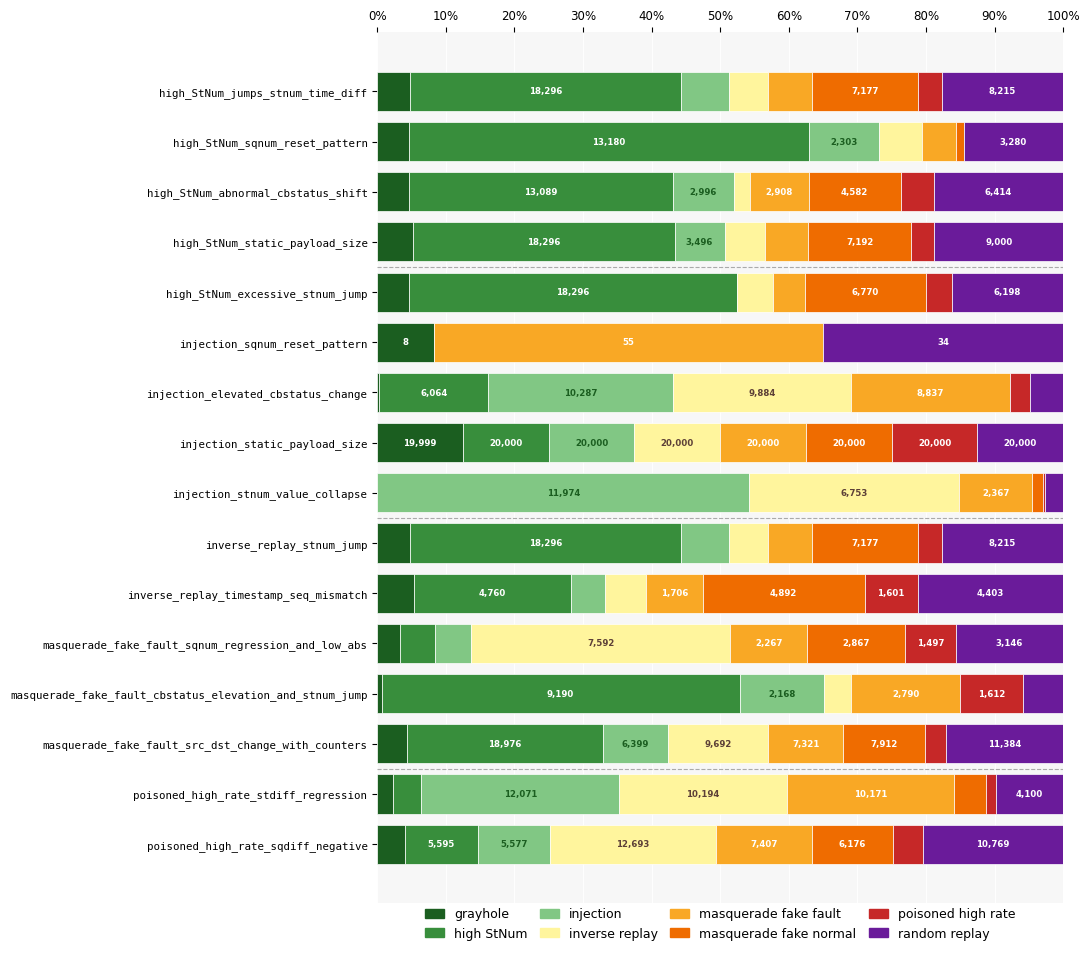

✓ Salvo em: matriz_regras_ataques_plot.png


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Ajuste o caminho do CSV aqui ────────────────────────────────
CSV_PATH = "matriz_regras_ataques.csv"
OUTPUT   = "matriz_regras_ataques_plot.png"
# ────────────────────────────────────────────────────────────────

# ── Lê direto o CSV já computado pelo script anterior ───────────
df = pd.read_csv(CSV_PATH, index_col="Regra")
df = df.drop(columns=["normal"], errors="ignore")
df = df[df.sum(axis=1) > 0]
df_pct = df.div(df.sum(axis=1), axis=0) * 100

# ── Paleta: cores fixas para classes conhecidas,
#    fallback automático para qualquer classe nova ───────────────
KNOWN_COLORS = {
    "grayhole":               "#1b5e20",
    "high_StNum":             "#388e3c",
    "injection":              "#81c784",
    "inverse_replay":         "#fff59d",
    "masquerade_fake_fault":  "#f9a825",
    "masquerade_fake_normal": "#ef6c00",
    "poisoned_high_rate":     "#c62828",
    "random_replay":          "#6a1b9a",
}

KNOWN_TEXT = {
    "grayhole":               "white",
    "high_StNum":             "white",
    "injection":              "#1b5e20",
    "inverse_replay":         "#5d4037",
    "masquerade_fake_fault":  "white",
    "masquerade_fake_normal": "white",
    "poisoned_high_rate":     "white",
    "random_replay":          "white",
}

# Paleta de fallback para classes não mapeadas
_FALLBACK_PALETTE = plt.cm.tab20.colors
attacks = df_pct.columns.tolist()

def _luminance(hex_color):
    """Retorna luminância relativa (0–1) de uma cor hex."""
    c = hex_color.lstrip("#")
    r, g, b = (int(c[i:i+2], 16) / 255 for i in (0, 2, 4))
    def lin(v): return v / 12.92 if v <= 0.04045 else ((v + 0.055) / 1.055) ** 2.4
    return 0.2126 * lin(r) + 0.7152 * lin(g) + 0.0722 * lin(b)

attack_colors = {}
text_color_map = {}
_fallback_idx = 0
for atk in attacks:
    if atk in KNOWN_COLORS:
        attack_colors[atk] = KNOWN_COLORS[atk]
        text_color_map[atk] = KNOWN_TEXT[atk]
    else:
        color = "#{:02x}{:02x}{:02x}".format(
            *[int(c * 255) for c in _FALLBACK_PALETTE[_fallback_idx % 20][:3]]
        )
        attack_colors[atk] = color
        text_color_map[atk] = "white" if _luminance(color) < 0.4 else "#333333"
        _fallback_idx += 1

# ── Plot ─────────────────────────────────────────────────────────
rules      = df_pct.index.tolist()
n_rules    = len(rules)
fig_height = max(10, n_rules * 0.48)

fig, ax = plt.subplots(figsize=(11, fig_height))
rule_labels = [r.replace("rule_", "") for r in rules]

lefts = np.zeros(n_rules)
for attack in attacks:
    color    = attack_colors[attack]
    txt_col  = text_color_map[attack]
    pct_vals = df_pct[attack].values
    abs_vals = df[attack].values
    ax.barh(
        range(n_rules), pct_vals, left=lefts,
        color=color, edgecolor="white", linewidth=0.5, height=0.78
    )
    for j, (pct, abv, l) in enumerate(zip(pct_vals, abs_vals, lefts)):
        if pct >= 7:
            ax.text(
                l + pct / 2, j, f"{int(abv):,}",
                ha="center", va="center",
                fontsize=6.2, color=txt_col, fontweight="bold"
            )
    lefts += pct_vals

ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 10)], fontsize=8.5)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", bottom=False, top=True, labelbottom=False, labeltop=True)

ax.set_yticks(range(n_rules))
ax.set_yticklabels(rule_labels, fontsize=7.8, fontfamily="monospace")
ax.invert_yaxis()

separators = [3.5, 8.5, 13.5, 16.5, 21.5, 25.5, 28.5]
for s in separators:
    if s < n_rules:
        ax.axhline(s, color="#aaaaaa", linewidth=0.8, linestyle="--", zorder=2)

ax.set_axisbelow(True)
ax.xaxis.grid(True, color="white", linewidth=0.7)
ax.set_facecolor("#f7f7f7")
for spine in ax.spines.values():
    spine.set_visible(False)

patches = [
    mpatches.Patch(color=attack_colors[a], label=a.replace("_", " "))
    for a in attacks
]
ax.legend(
    handles=patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.055),
    ncol=4, fontsize=9,
    frameon=False,
    handlelength=1.5,
    columnspacing=1.0
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUT, dpi=180, bbox_inches="tight")
plt.show()
print(f"✓ Salvo em: {OUTPUT}")

---
## 10. Considerações Finais

Este trabalho apresentou um pipeline orientado por LLM que automatiza a geração de regras de detecção para IDS baseados em especificação em subestações IEC 61850.

### Contribuições principais

- **Pipeline plug-and-play** end-to-end: do dataset rotulado às regras executáveis
- **Redução da dependência de especialistas** para criação manual de regras
- **Baixo overhead operacional**: regras Python leves adequadas a ambientes em tempo real
- **Reprodutibilidade**: parâmetros configuráveis e artefatos rastreáveis

### Limitações e trabalhos futuros

- Validação em hardware real de subestação (não apenas simulado)
- Avaliação com mais classes de ataque do dataset ERENO
- Comparação com abordagens de ML supervisionado
- Adaptação automática a novos padrões de ataque via atualização incremental

> **Repositório:** https://github.com/sequincozes/CounselorNode

---
## 11. Referências

- **Commission, I. E.** (2003). Communication networks and systems in substations - Part 8-1: SCSM. IET.

- **Hong, J. and Liu, C.** (2019). Intelligent electronic devices with collaborative intrusion detection systems. *IEEE Transactions on Smart Grid*, 10(1):271–281.

- **Hong, J., Liu, C., and Govindarasu, M.** (2014a). Detection of Cyber Intrusions Using Network-Based Multicast Messages for Substation Automation. *ISGT*, IEEE.

- **Hong, J., Liu, C., and Govindarasu, M.** (2014b). Integrated anomaly detection for cyber security of the substations. *IEEE Transactions on Smart Grid*, 5(4):1643–1653.

- **Kwon, Y. et al.** (2015). A behavior-based intrusion detection technique for smart grid infrastructure. *IEEE Eindhoven PowerTech*.

- **Malik, H., Alotaibi, M. A., and Almutairi, A.** (2022). Cyberattacks identification in IEC 61850 based substation using proximal SVM. *Journal of Intelligent & Fuzzy Systems*, 42(2):1213–1222.

- **Quincozes, S. E. et al.** (2021). A survey on intrusion detection and prevention systems in digital substations. *Computer Networks*, 184:107679.

- **Quincozes, S. E. et al.** (2022). ERENO: An Extensible Tool for Generating Realistic IEC–61850 Intrusion Detection Datasets. PhD thesis, UFF.

- **Yang, Y. et al.** (2016a). Intrusion detection system for IEC 61850 based smart substations. *IEEE PESGM*.

- **Yang, Y. et al.** (2016b). Multidimensional intrusion detection system for IEC 61850-based SCADA networks. *IEEE Transactions on Power Delivery*, 32(2):1068–1078.